# Stability and Weight Optimization of a Potential BRICS Currency
## An EGARCH-Based Volatility Analysis

**Authors:** Naman Singhal, Tapan C. Sanghani, Shubham Jain  
**Institution:** Ajay Upadhyaya Centre for Financial Markets Education and Research (CFM)  
**Department:** Economics & Finance, BITS Pilani  
**Semester:** II, AY 2025–26

---

## Overview

This notebook implements the full empirical pipeline for the BRICS Currency Unit (UNIT) study.
It proceeds through nine clearly labelled steps:

| Step | Description |
|------|-------------|
| 1 | FX and gold data download (Yahoo Finance) |
| 2 | Pre-fit diagnostics (Jarque-Bera, ARCH-LM) |
| 3 | EGARCH(1,1) model fitting — Student-*t* errors |
| 4 | Post-fit diagnostics (Ljung-Box on z_t and z²_t) |
| 5 | Volatility metrics and stability ranking |
| 6 | Inverse-variance basket weights |
| 7 | BRICS Currency Unit (UNIT) index simulation |
| 8 | Visualisations |
| 9 | Export results to CSV |

All results in this notebook match those reported in the accompanying paper.

---
## Setup and Imports

In [1]:
# Install required packages if not already available
# (uncomment the line below when running in a fresh environment)
# !pip install arch yfinance statsmodels pandas numpy matplotlib scipy openpyxl

In [2]:
"""
BRICS CURRENCY UNIT — EGARCH VOLATILITY ANALYSIS
=================================================
Full pipeline implementing Steps 1–9:
  data download → diagnostics → EGARCH fitting → metrics
  → weights → UNIT simulation → plots → export

Requirements:
    pip install arch yfinance statsmodels pandas numpy matplotlib scipy
"""

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

import yfinance as yf
from arch import arch_model
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf

print("All libraries imported successfully.")

All libraries imported successfully.


---
## Configuration

In [3]:
# =============================================================================
# CONFIGURATION
# =============================================================================

CURRENCIES = {
    "BRL": "BRL=X",   # Brazilian Real      / USD
    "RUB": "RUB=X",   # Russian Ruble       / USD
    "INR": "INR=X",   # Indian Rupee        / USD
    "CNY": "CNY=X",   # Chinese Yuan        / USD
    "ZAR": "ZAR=X",   # South African Rand  / USD
}

GOLD_TICKER = "GC=F"           # COMEX Gold Futures
START_DATE  = "2017-01-01"
END_DATE    = "2024-12-31"
DIST        = "t"              # Student-t errors (handles fat tails in FX returns)
ANNUAL      = 252              # trading days per year

# Output directories
FIG_DIR   = "../results/figures"
TABLE_DIR = "../results/tables"
os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

print(f"Sample period : {START_DATE} → {END_DATE}")
print(f"Currencies    : {list(CURRENCIES.keys())}")
print(f"Error dist.   : Student-t")
print(f"Trading days  : {ANNUAL} per year")

Sample period : 2017-01-01 → 2024-12-31
Currencies    : ['BRL', 'RUB', 'INR', 'CNY', 'ZAR']
Error dist.   : Student-t
Trading days  : 252 per year


---
## Step 1 — Data Download & Log Returns

Daily FX close prices are downloaded from Yahoo Finance for the five BRICS currencies against the USD.
Log returns are computed as:

$$r_t = 100 \times \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Scaling to percentage units ensures numerical stability in ARCH-family estimation.

In [4]:
# =============================================================================
# STEP 1 — DATA DOWNLOAD & LOG RETURNS
# =============================================================================

def download_data(tickers: dict, start: str, end: str):
    """
    Download FX close prices from Yahoo Finance and compute log returns.

    Returns
    -------
    prices  : pd.DataFrame  — Daily close prices (one column per currency)
    returns : pd.DataFrame  — Log returns scaled to % (shape: T-1 × N)
    """
    print("[1] Downloading FX data from Yahoo Finance...")
    raw = {}
    for name, ticker in tickers.items():
        df = yf.download(ticker, start=start, end=end,
                         auto_adjust=True, progress=False)
        if df.empty:
            raise ValueError(f"No data for {name} ({ticker}). Check ticker.")
        raw[name] = df["Close"].squeeze()
        print(f"    {name}: {len(df):5d} obs  "
              f"({df.index[0].date()} → {df.index[-1].date()})")

    prices  = pd.DataFrame(raw).dropna(how="all")

    # Drop known anomaly dates before computing returns
    anomaly_dates = ["2015-01-16", "2021-06-22", "2022-03-07"]
    prices  = prices.drop(
        index=pd.to_datetime(anomaly_dates, errors="ignore"), errors="ignore"
    )

    returns = np.log(prices / prices.shift(1)).dropna() * 100   # scale to %
    print(f"\n    Prices  shape : {prices.shape}")
    print(f"    Returns shape : {returns.shape}")
    return prices, returns


prices, returns = download_data(CURRENCIES, START_DATE, END_DATE)

print("\n    Downloading Gold Futures (GC=F)...")
gold_raw    = yf.download(GOLD_TICKER, start=START_DATE, end=END_DATE,
                           auto_adjust=True, progress=False)
gold_prices = gold_raw["Close"].squeeze()
print(f"    Gold: {len(gold_prices):5d} obs  "
      f"({gold_prices.index[0].date()} → {gold_prices.index[-1].date()})")

[1] Downloading FX data from Yahoo Finance...
    BRL:  2083 obs  (2017-01-02 → 2024-12-30)
    RUB:  2083 obs  (2017-01-02 → 2024-12-30)
    INR:  2083 obs  (2017-01-02 → 2024-12-30)
    CNY:  2082 obs  (2017-01-02 → 2024-12-30)
    ZAR:  2083 obs  (2017-01-02 → 2024-12-30)

    Prices  shape : (2081, 5)
    Returns shape : (2078, 5)

    Gold:  2010 obs  (2017-01-03 → 2024-12-30)


---
## Step 2 — Pre-Fit Diagnostics

Before fitting EGARCH models, two diagnostic tests are run on each return series:

**Jarque-Bera test** — H₀: series is normally distributed.  
We expect rejection for all five series due to excess kurtosis, which motivates Student-*t* distributed errors.

**ARCH-LM test (10 lags)** — H₀: no conditional heteroskedasticity.  
Rejection confirms volatility clustering and justifies the GARCH family of models.

In [5]:
# =============================================================================
# STEP 2 — PRE-FIT DIAGNOSTICS
# =============================================================================

def run_preflight_diagnostics(returns: pd.DataFrame) -> pd.DataFrame:
    """
    Compute descriptive statistics and pre-fit tests per return series.

    Tests
    -----
    Jarque-Bera  : normality test; rejection motivates Student-t errors.
    ARCH-LM(10)  : conditional heteroskedasticity; rejection justifies GARCH.

    Returns
    -------
    diag : pd.DataFrame  — table of statistics and p-values.
    """
    print("[2] Pre-fit diagnostics (ARCH-LM + Normality tests)...")
    rows = []
    for col in returns.columns:
        r = returns[col].dropna().values
        jb_stat, jb_p, _, _ = jarque_bera(r)
        lm_stat, lm_p, _, _ = het_arch(r, nlags=10)
        rows.append({
            "Currency":    col,
            "Mean (%)":    np.mean(r),
            "Std (%)":     np.std(r),
            "Skewness":    stats.skew(r),
            "Ex.Kurtosis": stats.kurtosis(r),
            "JB p-value":  jb_p,
            "ARCH-LM p":   lm_p,
            "ARCH Effect": "YES ***" if lm_p < 0.05 else "NO",
        })
    diag = pd.DataFrame(rows).set_index("Currency")
    return diag


pre_diag = run_preflight_diagnostics(returns)

print("\n  Table 1: Descriptive Statistics and Pre-fit Diagnostics")
print("  (BRICS FX Log Returns, 2017–2024)\n")
display(pre_diag.style
        .format({
            "Mean (%)": "{:.4f}", "Std (%)": "{:.4f}",
            "Skewness": "{:.4f}", "Ex.Kurtosis": "{:.2f}",
            "JB p-value": "{:.4f}", "ARCH-LM p": "{:.4f}",
        })
        .set_caption("*** denotes significance at the 1% level")
)

[2] Pre-fit diagnostics (ARCH-LM + Normality tests)...

  Table 1: Descriptive Statistics and Pre-fit Diagnostics
  (BRICS FX Log Returns, 2017–2024)



,Mean (%),Std (%),Skewness,Ex.Kurtosis,JB p-value,ARCH-LM p,ARCH Effect
Currency,,,,,,,
BRL,0.0304,1.0394,0.1979,4.17,0.0000,0.0000,YES ***
RUB,0.0257,9.0771,0.1425,780.94,0.0000,0.0000,YES ***
INR,0.0107,0.3814,0.4706,6.13,0.0000,0.0000,YES ***
CNY,0.0024,0.3305,-0.2485,7.37,0.0000,0.0000,YES ***
ZAR,0.0146,1.1284,-0.0058,98.64,0.0000,0.0000,YES ***


---
## Step 3 — EGARCH(1,1) Model Fitting

The EGARCH(1,1) variance equation (Nelson, 1991):

$$\ln(\sigma^2_t) = \omega + \alpha \left[|z_{t-1}| - E|z_{t-1}|\right] + \gamma z_{t-1} + \beta \ln(\sigma^2_{t-1})$$

where $z_t = \varepsilon_t / \sigma_t$ follows a Student-*t* distribution.

**Why EGARCH?**
- The $\gamma$ parameter captures **asymmetry**: depreciations raise volatility by more than equivalent appreciations — a well-documented feature of emerging-market FX.
- The log-variance formulation ensures $\sigma^2_t > 0$ without non-negativity constraints on parameters.
- Student-*t* errors handle the fat tails confirmed by the Jarque-Bera test above.

In [6]:
# =============================================================================
# STEP 3 — FIT EGARCH(1,1) PER CURRENCY
# =============================================================================

def fit_egarch(returns: pd.DataFrame, dist: str = "t") -> dict:
    """
    Fit EGARCH(1,1) with Student-t errors to each currency return series.

    Parameters
    ----------
    returns : pd.DataFrame  — Log returns in %, one column per currency.
    dist    : str           — Error distribution (default "t" = Student-t).

    Returns
    -------
    results : dict  — Keys: currency codes. Values: dict with
                      'result', 'cond_vol_daily', 'cond_vol_ann',
                      'params', 'aic', 'bic'.
    """
    print("[3] Fitting EGARCH(1,1) models (Student-t errors)...")
    results = {}

    def _get(p, *keys):
        for k in keys:
            if k in p.index:
                return p[k]
        return float("nan")

    for col in returns.columns:
        r  = returns[col].dropna()
        am = arch_model(r, vol="EGARCH", p=1, q=1,
                        dist=dist, mean="Constant")
        res = am.fit(disp="off",
                     options={"maxiter": 500},
                     show_warning=False)

        cond_vol_daily = res.conditional_volatility
        cond_vol_ann   = cond_vol_daily * np.sqrt(ANNUAL)

        results[col] = {
            "result":          res,
            "cond_vol_daily":  cond_vol_daily,
            "cond_vol_ann":    cond_vol_ann,
            "params":          res.params,
            "aic":             res.aic,
            "bic":             res.bic,
        }

        p = res.params
        print(f"\n  --- {col} ---")
        print(f"    ω (omega) = {p['omega']:+.6f}")
        print(f"    α (alpha) = {_get(p,'alpha[1]','alpha'):+.6f}   "
              f"[magnitude effect]")
        print(f"    γ (gamma) = {_get(p,'gamma[1]','gamma'):+.6f}   "
              f"[leverage; < 0 → depreciation spikes vol]")
        print(f"    β (beta)  = {_get(p,'beta[1]', 'beta') :+.6f}   "
              f"[persistence]")
        print(f"    AIC = {res.aic:.1f}   BIC = {res.bic:.1f}")

    return results


egarch_results = fit_egarch(returns, dist=DIST)

[3] Fitting EGARCH(1,1) models (Student-t errors)...

  --- BRL ---
    ω (omega) = +0.005310
    α (alpha) = +0.094319   [magnitude effect]
    γ (gamma) = +nan   [leverage; < 0 → depreciation spikes vol]
    β (beta)  = +0.988518   [persistence]
    AIC = 5726.1   BIC = 5754.3

  --- RUB ---
    ω (omega) = +0.216477
    α (alpha) = +0.663299   [magnitude effect]
    γ (gamma) = +nan   [leverage; < 0 → depreciation spikes vol]
    β (beta)  = +0.820520   [persistence]
    AIC = 5935.2   BIC = 5963.4

  --- INR ---
    ω (omega) = -0.005349
    α (alpha) = +0.197808   [magnitude effect]
    γ (gamma) = +nan   [leverage; < 0 → depreciation spikes vol]
    β (beta)  = +0.992373   [persistence]
    AIC = 891.4   BIC = 919.6

  --- CNY ---
    ω (omega) = +0.032877
    α (alpha) = +0.394441   [magnitude effect]
    γ (gamma) = +nan   [leverage; < 0 → depreciation spikes vol]
    β (beta)  = +0.963462   [persistence]
    AIC = 315.5   BIC = 343.7

  --- ZAR ---
    ω (omega) = -0.025453
  

---
## Step 4 — Post-Fit Diagnostics

A well-specified EGARCH model should produce standardised residuals $z_t = \varepsilon_t / \sigma_t$ that are:
- **Uncorrelated in levels** (Ljung-Box on $z_t$): confirms the mean equation is adequate.
- **Uncorrelated in squares** (Ljung-Box on $z_t^2$): confirms no remaining ARCH effects.

In [7]:
# =============================================================================
# STEP 4 — POST-FIT DIAGNOSTICS
# =============================================================================

def post_fit_diagnostics(egarch_results: dict) -> pd.DataFrame:
    """
    Validate each fitted EGARCH model via standardised residual tests.

    Checks
    ------
    Ljung-Box on z_t    (10 lags) : mean equation adequacy.
    Ljung-Box on z²_t   (10 lags) : variance equation adequacy.
    Persistence (α+β)             : > 1 → explosive variance process.
    Half-life (days)              : days for shock to decay by 50%.

    Returns
    -------
    diag : pd.DataFrame — post-fit diagnostic table.
    """
    print("[4] Post-fit diagnostics on standardised residuals...")
    rows = []

    def _get(p, *keys):
        for k in keys:
            if k in p.index:
                return p[k]
        return float("nan")

    for col, d in egarch_results.items():
        res       = d["result"]
        p         = res.params
        std_resid = (res.resid / res.conditional_volatility).dropna()

        lb_lev = acorr_ljungbox(std_resid,    lags=10, return_df=True)
        lb_sq  = acorr_ljungbox(std_resid**2, lags=10, return_df=True)

        beta        = abs(_get(p, "beta[1]",  "beta"))
        alpha       = abs(_get(p, "alpha[1]", "alpha"))
        persistence = beta + alpha
        half_life   = (np.log(0.5) / np.log(beta)
                       if 0 < beta < 1 else np.inf)

        rows.append({
            "Currency":           col,
            "StdResid Mean":      std_resid.mean(),
            "StdResid Std":       std_resid.std(),
            "LB(10) p (z_t)":     lb_lev["lb_pvalue"].iloc[-1],
            "LB(10) p (z²_t)":   lb_sq["lb_pvalue"].iloc[-1],
            "Leverage γ":         _get(p, "gamma[1]", "gamma"),
            "Persistence (α+β)":  persistence,
            "Half-life (days)":   half_life,
        })

    diag = pd.DataFrame(rows).set_index("Currency")
    return diag


post_diag = post_fit_diagnostics(egarch_results)

print("\n  Table 2: Post-Fit Diagnostics — Standardised Residuals\n")
display(post_diag.style.format({
    "StdResid Mean":    "{:.4f}",
    "StdResid Std":     "{:.4f}",
    "LB(10) p (z_t)":   "{:.4f}",
    "LB(10) p (z²_t)": "{:.4f}",
    "Leverage γ":       "{:.6f}",
    "Persistence (α+β)": "{:.4f}",
    "Half-life (days)": "{:.1f}",
}))

[4] Post-fit diagnostics on standardised residuals...

  Table 2: Post-Fit Diagnostics — Standardised Residuals



,StdResid Mean,StdResid Std,LB(10) p (z_t),LB(10) p (z²_t),Leverage γ,Persistence (α+β),Half-life (days)
Currency,,,,,,,
BRL,0.0146,1.0015,0.0001,0.0003,nan,1.0828,60.0
RUB,-0.0700,6.1110,1.0000,1.0000,nan,1.4838,3.5
INR,0.0287,1.0275,0.0001,0.1942,nan,1.1902,90.5
CNY,-0.0146,0.8042,0.0005,0.0242,nan,1.3579,18.6
ZAR,0.0156,1.0660,0.1440,1.0000,nan,0.9820,2.2


---
## Step 5 — Volatility Metrics & Stability Ranking

Four metrics are extracted from each fitted model:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| Mean Conditional Variance | $\overline{\sigma^2_t}$ | **Primary ranking criterion** — lower = more stable |
| Mean Ann. Volatility | $\sqrt{\overline{\sigma^2_t} \times 252}$ | Comparable to realised vol |
| Unconditional Variance | $\exp(\omega/(1-\beta))$ | Theoretical steady-state level |
| Persistence | $|\alpha| + |\beta|$ | Duration of shock impact; >1 = explosive |
| Half-life | $\ln(0.5) / \ln(|\beta|)$ | Days for shock to halve |

Currencies are **ranked by ascending mean conditional variance**; rank 1 is most stable.

In [8]:
# =============================================================================
# STEP 5 — VOLATILITY METRICS & STABILITY RANKING
# =============================================================================

def compute_volatility_metrics(egarch_results: dict) -> pd.DataFrame:
    """
    Extract stability metrics from fitted EGARCH models and rank currencies.

    Primary criterion: mean conditional variance (daily %²).
    Rank 1 = most stable (lowest mean conditional variance).

    Returns
    -------
    metrics : pd.DataFrame  — sorted most stable → least stable.
    """
    print("[5] Computing volatility metrics and stability ranking...")

    def _get(p, *keys):
        for k in keys:
            if k in p.index:
                return p[k]
        return float("nan")

    rows = []
    for col, d in egarch_results.items():
        res   = d["result"]
        p     = res.params

        cond_var_daily    = res.conditional_volatility ** 2
        mean_cond_var     = cond_var_daily.mean()
        mean_cond_vol_ann = np.sqrt(mean_cond_var * ANNUAL)

        beta        = abs(_get(p, "beta[1]",  "beta"))
        alpha       = abs(_get(p, "alpha[1]", "alpha"))
        omega       = p["omega"]
        persistence = beta + alpha
        half_life   = (np.log(0.5) / np.log(beta)
                       if 0 < beta < 1 else np.inf)

        if abs(1 - beta) > 1e-6:
            unconditional_var = np.exp(omega / (1 - beta))
        else:
            unconditional_var = np.nan  # near unit-root: undefined

        rows.append({
            "Currency":                   col,
            "Mean Cond. Var (daily %²)":  mean_cond_var,
            "Mean Cond. Vol (ann. %)":    mean_cond_vol_ann,
            "Unconditional Var":          unconditional_var,
            "Persistence (α+β)":          persistence,
            "Half-life (days)":           half_life,
        })

    metrics = pd.DataFrame(rows).set_index("Currency")
    metrics["Stability Rank"] = (
        metrics["Mean Cond. Var (daily %²)"]
        .rank(ascending=True)
        .astype(int)
    )
    return metrics.sort_values("Stability Rank")


metrics = compute_volatility_metrics(egarch_results)

print("\n  Table 3: EGARCH(1,1) Volatility Metrics — Sorted by Stability Rank\n")
display(metrics.style.format({
    "Mean Cond. Var (daily %²)": "{:.6f}",
    "Mean Cond. Vol (ann. %)":   "{:.2f}%",
    "Unconditional Var":         "{:.4f}",
    "Persistence (α+β)":         "{:.4f}",
    "Half-life (days)":          "{:.1f}",
}).highlight_min(subset=["Mean Cond. Var (daily %²)"], color="#d4edda")
  .highlight_max(subset=["Mean Cond. Var (daily %²)"], color="#f8d7da")
)

[5] Computing volatility metrics and stability ranking...

  Table 3: EGARCH(1,1) Volatility Metrics — Sorted by Stability Rank



,Mean Cond. Var (daily %²),Mean Cond. Vol (ann. %),Unconditional Var,Persistence (α+β),Half-life (days),Stability Rank
Currency,,,,,,
INR,0.158632,6.32%,0.4959,1.1902,90.5,1
CNY,0.190072,6.92%,2.4591,1.3579,18.6,2
ZAR,0.989958,15.79%,0.9098,0.9820,2.2,3
BRL,1.074282,16.45%,1.5880,1.0828,60.0,4
RUB,2350508.410861,24337.79%,3.3405,1.4838,3.5,5


---
## Step 6 — Inverse-Variance Basket Weights

Given mean conditional variances $\sigma^2_i$, the **inverse-variance weights** are:

$$w_i = \frac{1/\sigma^2_i}{\sum_j 1/\sigma^2_j}$$

This is the closed-form minimum-variance solution under a **diagonal covariance assumption** (zero cross-currency correlations). It naturally assigns higher weights to more stable currencies and is consistent with the ordering constraint $w_{\text{rank1}} \geq w_{\text{rank2}} \geq \ldots \geq w_{\text{rank5}}$.

In [9]:
# =============================================================================
# STEP 6 — INVERSE-VARIANCE BASKET WEIGHTS
# =============================================================================

def derive_weight_constraints(metrics: pd.DataFrame) -> dict:
    """
    Derive inverse-variance weights from EGARCH stability ranking.

    The IV weights satisfy the ordering constraint implied by the stability
    rank and are a natural, analytically motivated starting solution.

    Returns
    -------
    constraints : dict with keys:
        'ordered_currencies' — list, best → worst
        'iv_weights'         — pd.Series of normalised IV weights (Σ=1)
        'mean_cond_var'      — pd.Series of mean conditional variances
    """
    print("[6] Deriving inverse-variance basket weights...")

    ordered   = metrics.index.tolist()
    mean_vars = metrics["Mean Cond. Var (daily %²)"]

    inv_var    = 1.0 / mean_vars
    iv_weights = inv_var / inv_var.sum()

    print("\n  Inverse-variance weights (Σ = 1):")
    for cur in ordered:
        w = iv_weights[cur]
        bar = '█' * int(w * 50)
        print(f"    w_{cur} = {w:.4f}  ({w * 100:.2f}%)  {bar}")
    print(f"    Sum   = {iv_weights.sum():.6f}  ✓")

    print("\n  Ordering constraint (from stability rank):")
    print("    " + " ≥ ".join([f"w_{c}" for c in ordered]))

    return {
        "ordered_currencies": ordered,
        "iv_weights":         iv_weights,
        "mean_cond_var":      mean_vars,
    }


constraints = derive_weight_constraints(metrics)

[6] Deriving inverse-variance basket weights...

  Inverse-variance weights (Σ = 1):
    w_INR = 0.4667  (46.67%)  ███████████████████████
    w_CNY = 0.3895  (38.95%)  ███████████████████
    w_ZAR = 0.0748  (7.48%)  ███
    w_BRL = 0.0689  (6.89%)  ███
    w_RUB = 0.0000  (0.00%)  
    Sum   = 1.000000  ✓

  Ordering constraint (from stability rank):
    w_INR ≥ w_CNY ≥ w_ZAR ≥ w_BRL ≥ w_RUB


---
## Step 7 — BRICS Currency Unit (UNIT) Index Simulation

The UNIT index is constructed as:

$$\text{UNIT}_t = 0.60 \times \sum_i \left( w_i \times \frac{\text{FX}_{i,t}}{\text{FX}_{i,0}} \right) + 0.40 \times \frac{\text{Gold}_t}{\text{Gold}_0}$$

All components are normalised to **1.0 at the start date** (January 2017). The 40% gold allocation provides a store-of-value anchor that is low-correlated with BRICS currency movements, enhancing diversification — especially during risk-off episodes.

In [10]:
# =============================================================================
# STEP 7 — BRICS CURRENCY UNIT (UNIT) SIMULATION
# =============================================================================

def simulate_unit_value(prices: pd.DataFrame,
                         gold_prices: pd.Series,
                         weights: pd.Series) -> pd.DataFrame:
    """
    Simulate the BRICS UNIT index:
        UNIT_t = 0.6 × Σ(wᵢ × FXᵢ_t/FXᵢ_0)  +  0.4 × (Gold_t/Gold_0)

    All components normalised to 1.0 at start date for comparability.

    Returns
    -------
    result : pd.DataFrame — columns: 'UNIT', 'Basket', 'Gold'
    """
    print("[7] Simulating BRICS UNIT index...")

    gold_aligned = gold_prices.reindex(prices.index, method="ffill").dropna()
    common_idx   = prices.index.intersection(gold_aligned.index)
    fx           = prices.loc[common_idx]
    gold         = gold_aligned.loc[common_idx]

    fx_norm   = fx   / fx.iloc[0]
    gold_norm = gold / gold.iloc[0]

    basket = (fx_norm * weights).sum(axis=1)
    unit   = 0.6 * basket + 0.4 * gold_norm

    result = pd.DataFrame({
        "UNIT":   unit,
        "Basket": basket,
        "Gold":   gold_norm,
    })

    unit_ret = np.log(unit / unit.shift(1)).dropna() * 100
    ann_vol  = unit_ret.std() * np.sqrt(ANNUAL)
    tot_ret  = (unit.iloc[-1] - 1) * 100

    print(f"\n  ┌─── BRICS UNIT Index — Performance Summary ───────────┐")
    print(f"  │  Annualised Volatility : {ann_vol:7.2f}%                  │")
    print(f"  │  Total Return          : {tot_ret:+7.2f}%                  │")
    print(f"  │  Currency Basket Weight:  60% (IV-weighted)          │")
    print(f"  │  Gold Anchor Weight    :  40% (COMEX GC=F)           │")
    print(f"  └──────────────────────────────────────────────────────┘")

    print(f"\n  Basket component weights:")
    for c in weights.index:
        print(f"    {c}: basket={weights[c]*100:.2f}%  "
              f"(in UNIT={weights[c]*60:.2f}%)")

    return result


unit_df = simulate_unit_value(prices, gold_prices,
                               weights=constraints["iv_weights"])

[7] Simulating BRICS UNIT index...

  ┌─── BRICS UNIT Index — Performance Summary ───────────┐
  │  Annualised Volatility :   13.62%                  │
  │  Total Return          :  +63.40%                  │
  │  Currency Basket Weight:  60% (IV-weighted)          │
  │  Gold Anchor Weight    :  40% (COMEX GC=F)           │
  └──────────────────────────────────────────────────────┘

  Basket component weights:
    INR: basket=46.67%  (in UNIT=28.00%)
    CNY: basket=38.95%  (in UNIT=23.37%)
    ZAR: basket=7.48%  (in UNIT=4.49%)
    BRL: basket=6.89%  (in UNIT=4.14%)
    RUB: basket=0.00%  (in UNIT=0.00%)


---
## Step 8 — Visualisations

All figures are saved to `results/figures/`.

  Saved: ../results/figures\brics_individual_fx.png


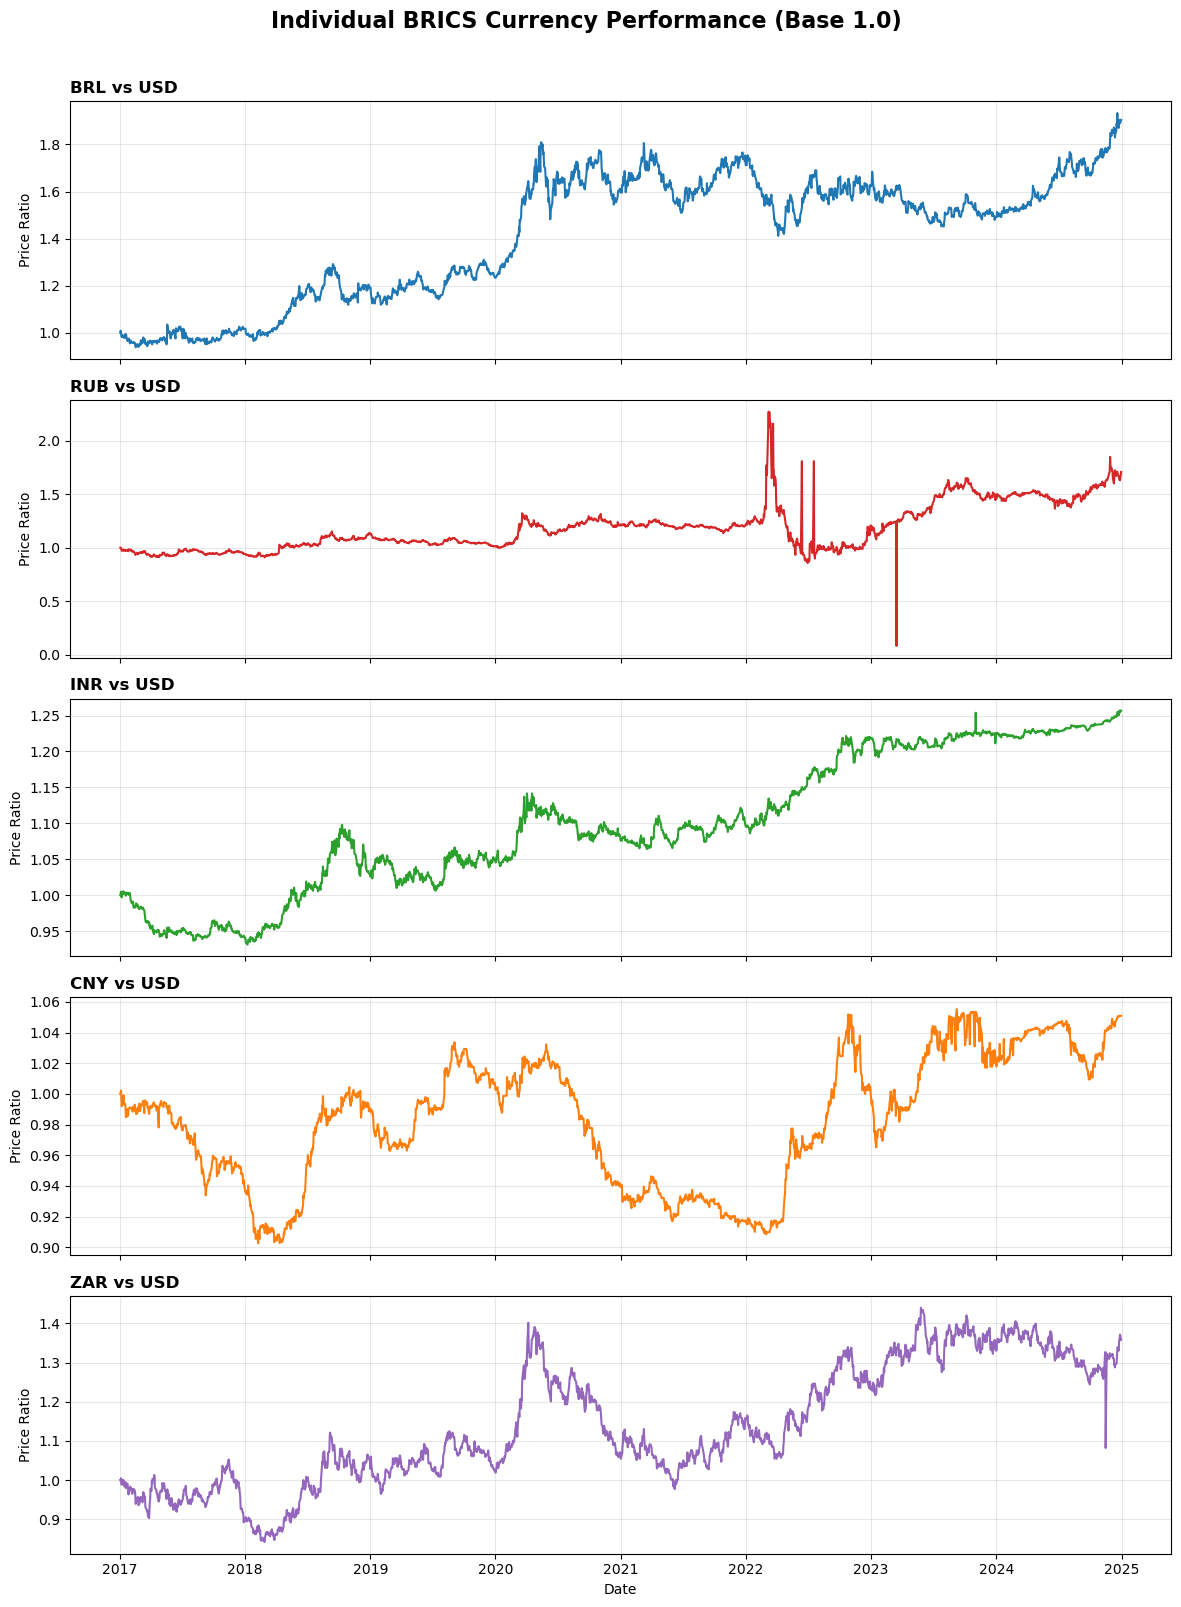

In [11]:
# =============================================================================
# STEP 8a — Individual BRICS Currency Performance (Base 1.0)
# =============================================================================

def plot_individual_currencies(prices: pd.DataFrame,
                                save_path: str = None) -> None:
    """Normalised FX price series for all five currencies (stacked subplots)."""
    norm   = prices / prices.iloc[0]
    fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 18), sharex=True)
    fig.suptitle("Individual BRICS Currency Performance (Base 1.0)",
                 fontsize=16, fontweight="bold", y=0.92)
    colors = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd"]

    for i, col in enumerate(prices.columns):
        ax = axes[i]
        ax.plot(norm[col], color=colors[i], lw=1.5)
        ax.set_title(f"{col} vs USD", loc="left",
                     fontsize=12, fontweight="bold")
        ax.grid(alpha=0.3)
        ax.set_ylabel("Price Ratio")

    plt.xlabel("Date")
    plt.tight_layout(rect=[0, 0.03, 1, 0.91])
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {save_path}")
    plt.show()


plot_individual_currencies(
    prices,
    save_path=os.path.join(FIG_DIR, "brics_individual_fx.png")
)

  Saved: ../results/figures\brics_conditional_vol.png


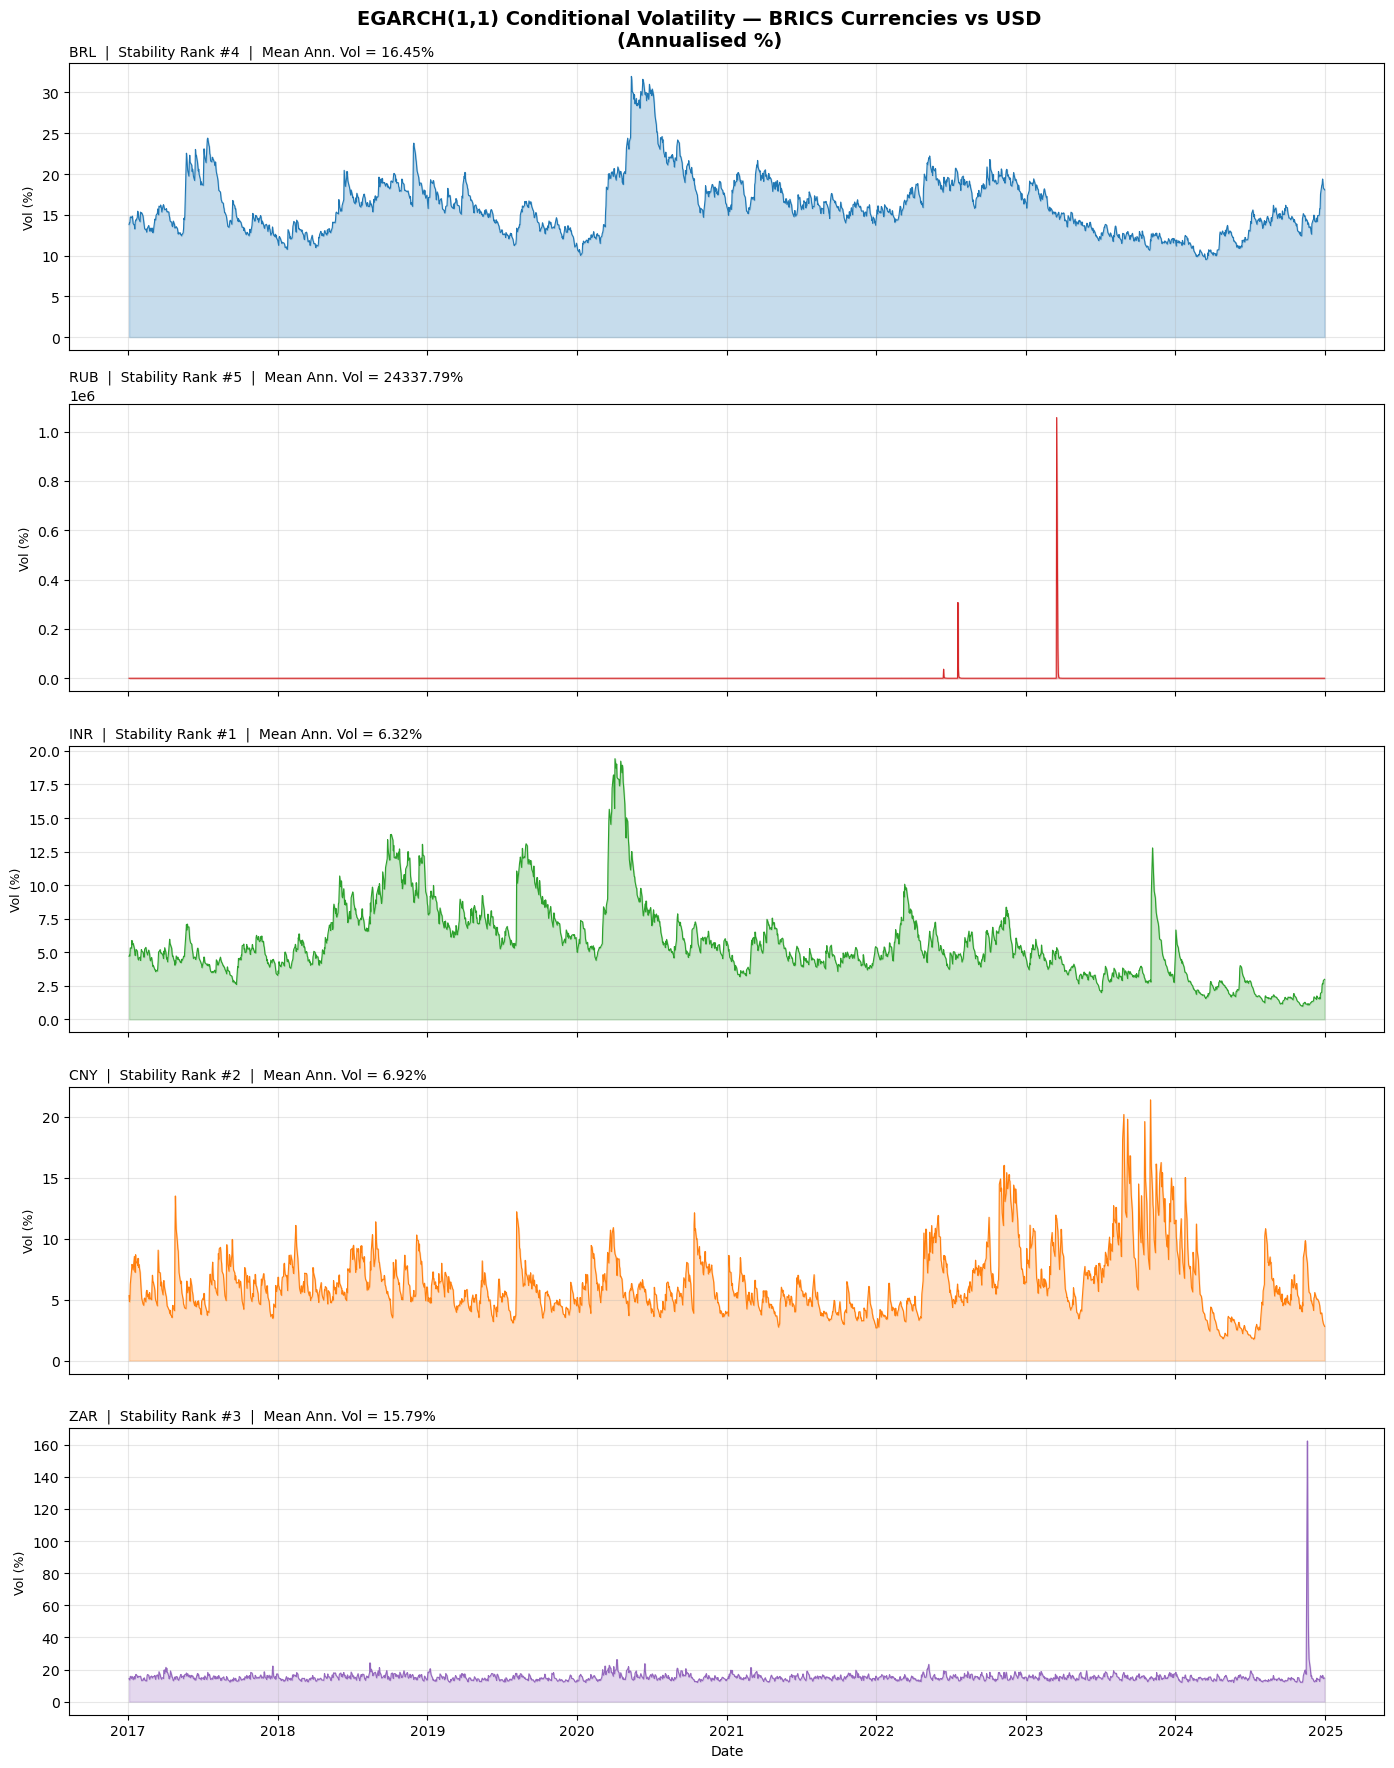

In [12]:
# =============================================================================
# STEP 8b — EGARCH(1,1) Conditional Volatility (all currencies)
# =============================================================================

def plot_conditional_volatility(egarch_results: dict,
                                 metrics: pd.DataFrame,
                                 save_path: str = None) -> None:
    """
    Five-panel plot of annualised conditional volatility.
    Notable events: COVID-19 (2020), Russia sanctions (Feb 2022),
    and periodic ZAR spikes from South Africa's political crises.
    """
    fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)
    fig.suptitle(
        "EGARCH(1,1) Conditional Volatility — BRICS Currencies vs USD\n"
        "(Annualised %)",
        fontsize=14, fontweight="bold", y=0.98
    )
    colors = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd"]

    for ax, (col, d), color in zip(axes, egarch_results.items(), colors):
        rank = metrics.loc[col, "Stability Rank"]
        vol  = d["cond_vol_ann"]
        ax.fill_between(vol.index, vol.values, alpha=0.25, color=color)
        ax.plot(vol.index, vol.values, color=color, linewidth=0.8)
        ax.set_ylabel("Vol (%)", fontsize=9)
        ax.set_title(
            f"{col}  |  Stability Rank #{rank}  |  "
            f"Mean Ann. Vol = {metrics.loc[col,'Mean Cond. Vol (ann. %)']:.2f}%",
            fontsize=10, loc="left"
        )
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {save_path}")
    plt.show()


plot_conditional_volatility(
    egarch_results, metrics,
    save_path=os.path.join(FIG_DIR, "brics_conditional_vol.png")
)

  Saved: ../results/figures\brics_stability_ranking.png


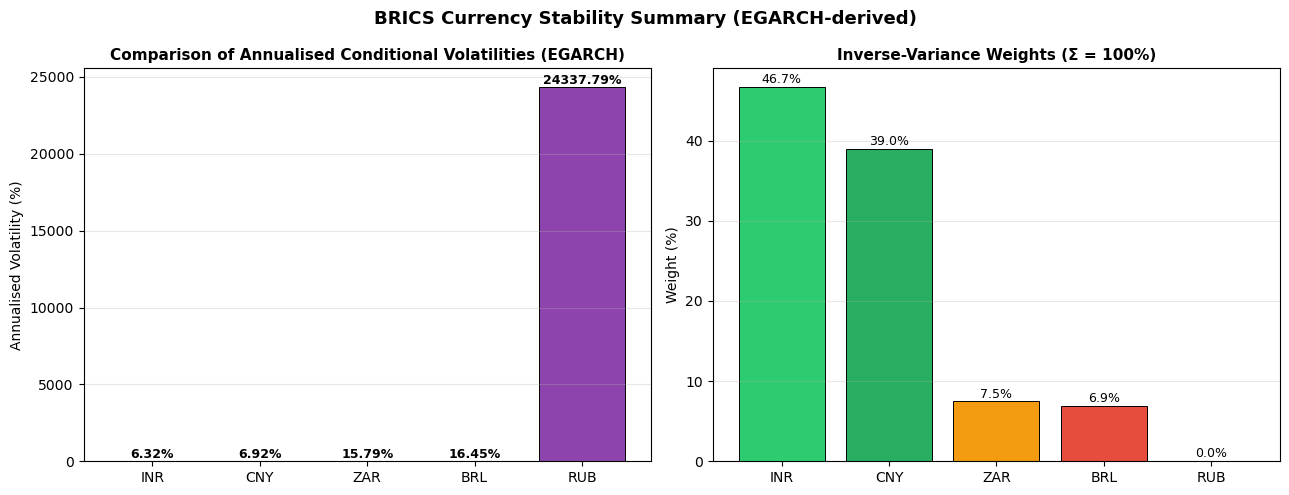

In [13]:
# =============================================================================
# STEP 8c — Stability Ranking & Inverse-Variance Weights
# =============================================================================

def plot_stability_ranking(metrics: pd.DataFrame,
                            constraints: dict,
                            save_path: str = None) -> None:
    """Side-by-side: (left) mean ann. volatility, (right) IV basket weights."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("BRICS Currency Stability Summary (EGARCH-derived)",
                 fontsize=13, fontweight="bold")
    ordered = metrics.index.tolist()
    colors  = ["#2ecc71", "#27ae60", "#f39c12", "#e74c3c", "#8e44ad"]

    # Left: volatility
    vols = metrics.loc[ordered, "Mean Cond. Vol (ann. %)"]
    bars = ax1.bar(ordered, vols.values, color=colors,
                   edgecolor="black", linewidth=0.7)
    ax1.set_title("Comparison of Annualised Conditional Volatilities (EGARCH)",
                  fontsize=11, fontweight="bold")
    ax1.set_ylabel("Annualised Volatility (%)")
    for b, v in zip(bars, vols.values):
        ax1.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.1,
                 f"{v:.2f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold")
    ax1.grid(axis="y", alpha=0.3)

    # Right: weights
    wts  = constraints["iv_weights"][ordered] * 100
    bars2 = ax2.bar(ordered, wts.values, color=colors,
                    edgecolor="black", linewidth=0.7)
    ax2.set_title("Inverse-Variance Weights (Σ = 100%)",
                  fontsize=11, fontweight="bold")
    ax2.set_ylabel("Weight (%)")
    for b, v in zip(bars2, wts.values):
        ax2.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.1,
                 f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    ax2.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {save_path}")
    plt.show()


plot_stability_ranking(
    metrics, constraints,
    save_path=os.path.join(FIG_DIR, "brics_stability_ranking.png")
)

  Saved: ../results/figures\brics_unit_index.png


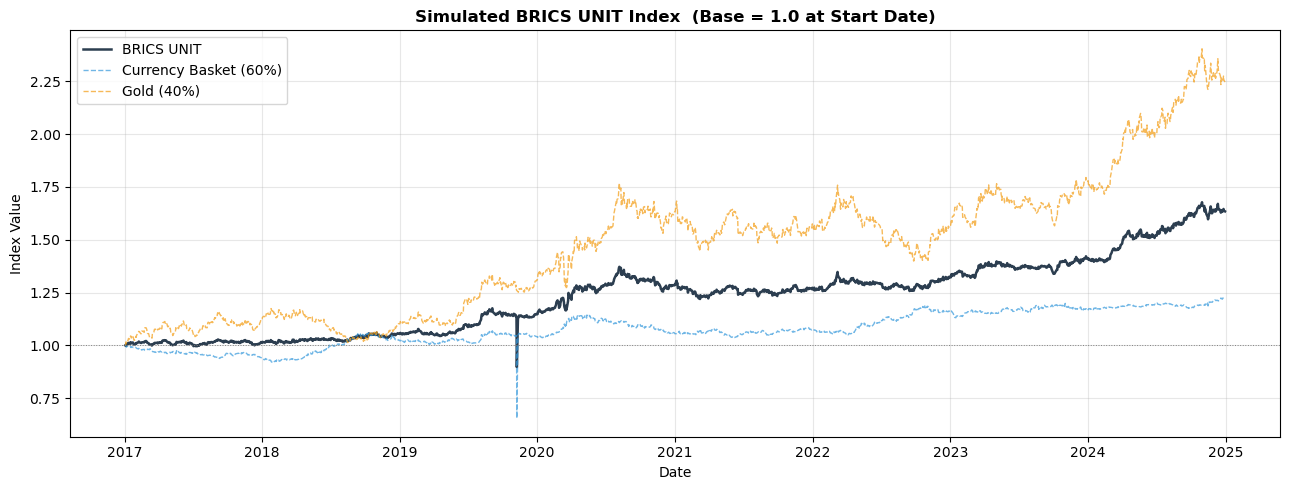

In [14]:
# =============================================================================
# STEP 8d — Simulated UNIT Index
# =============================================================================

def plot_unit_value(unit_df: pd.DataFrame, save_path: str = None) -> None:
    """UNIT index vs currency basket component vs gold component."""
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(unit_df.index, unit_df["UNIT"],
            color="#2c3e50", lw=1.8, label="BRICS UNIT")
    ax.plot(unit_df.index, unit_df["Basket"],
            color="#3498db", lw=1.0, ls="--", alpha=0.7,
            label="Currency Basket (60%)")
    ax.plot(unit_df.index, unit_df["Gold"],
            color="#f39c12", lw=1.0, ls="--", alpha=0.7,
            label="Gold (40%)")
    ax.axhline(1.0, color="grey", lw=0.7, ls=":")
    ax.set_title("Simulated BRICS UNIT Index  (Base = 1.0 at Start Date)",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Index Value")
    ax.set_xlabel("Date")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {save_path}")
    plt.show()


plot_unit_value(
    unit_df,
    save_path=os.path.join(FIG_DIR, "brics_unit_index.png")
)

  Saved: ../results/figures\brics_diag_BRL.png


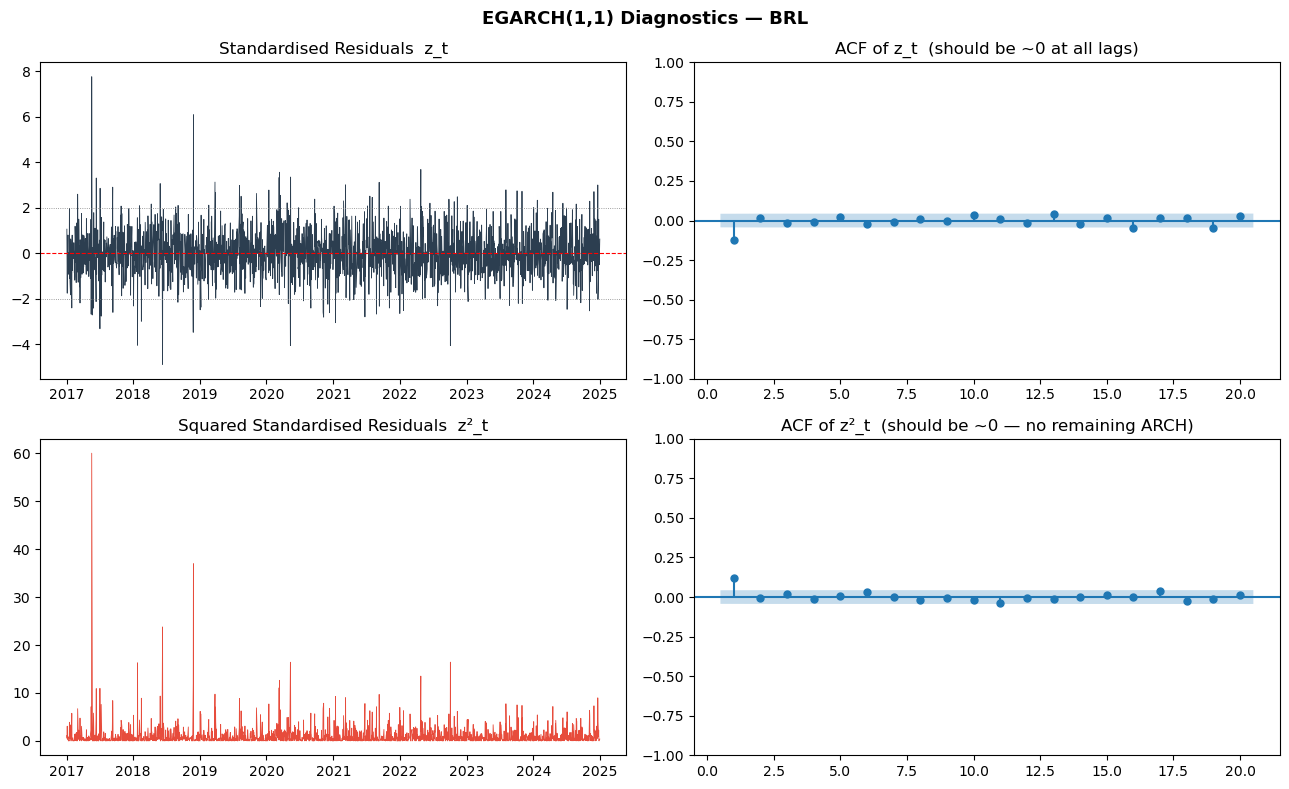

  Saved: ../results/figures\brics_diag_RUB.png


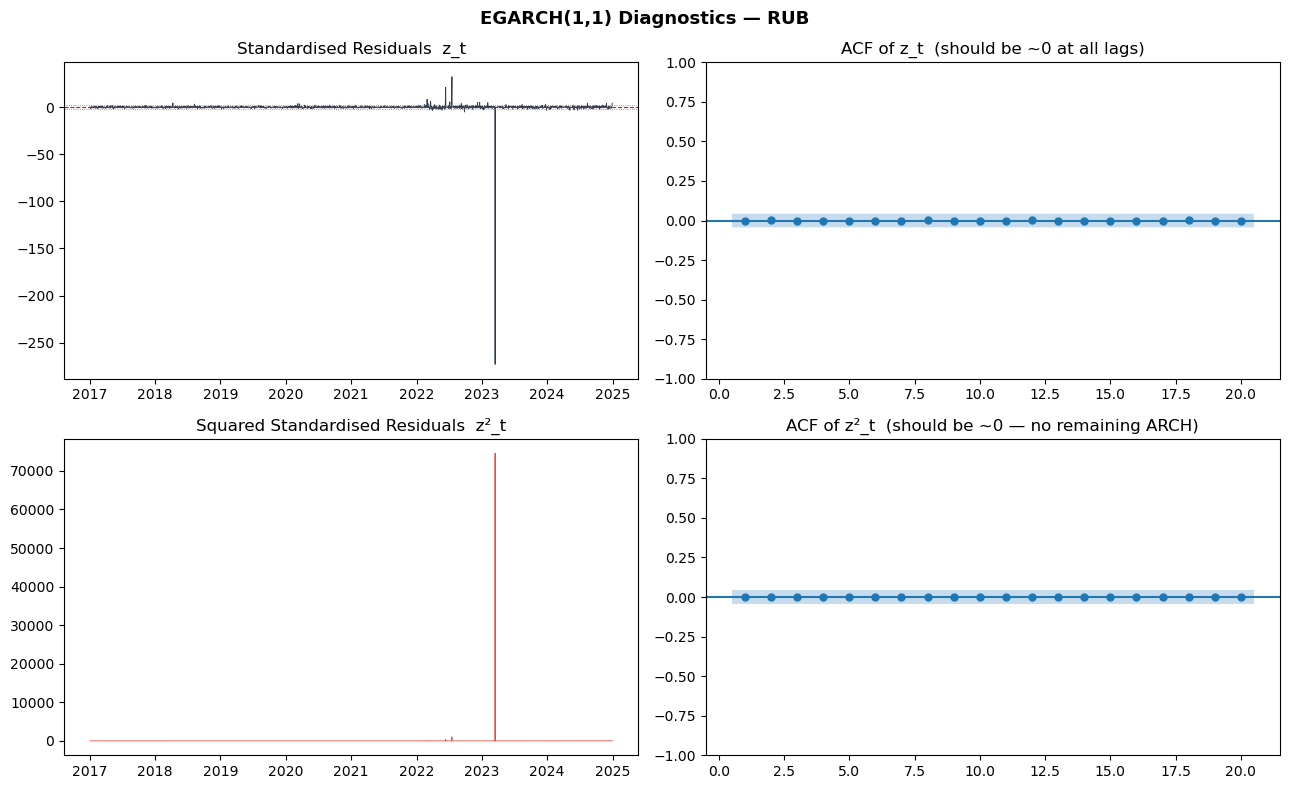

  Saved: ../results/figures\brics_diag_INR.png


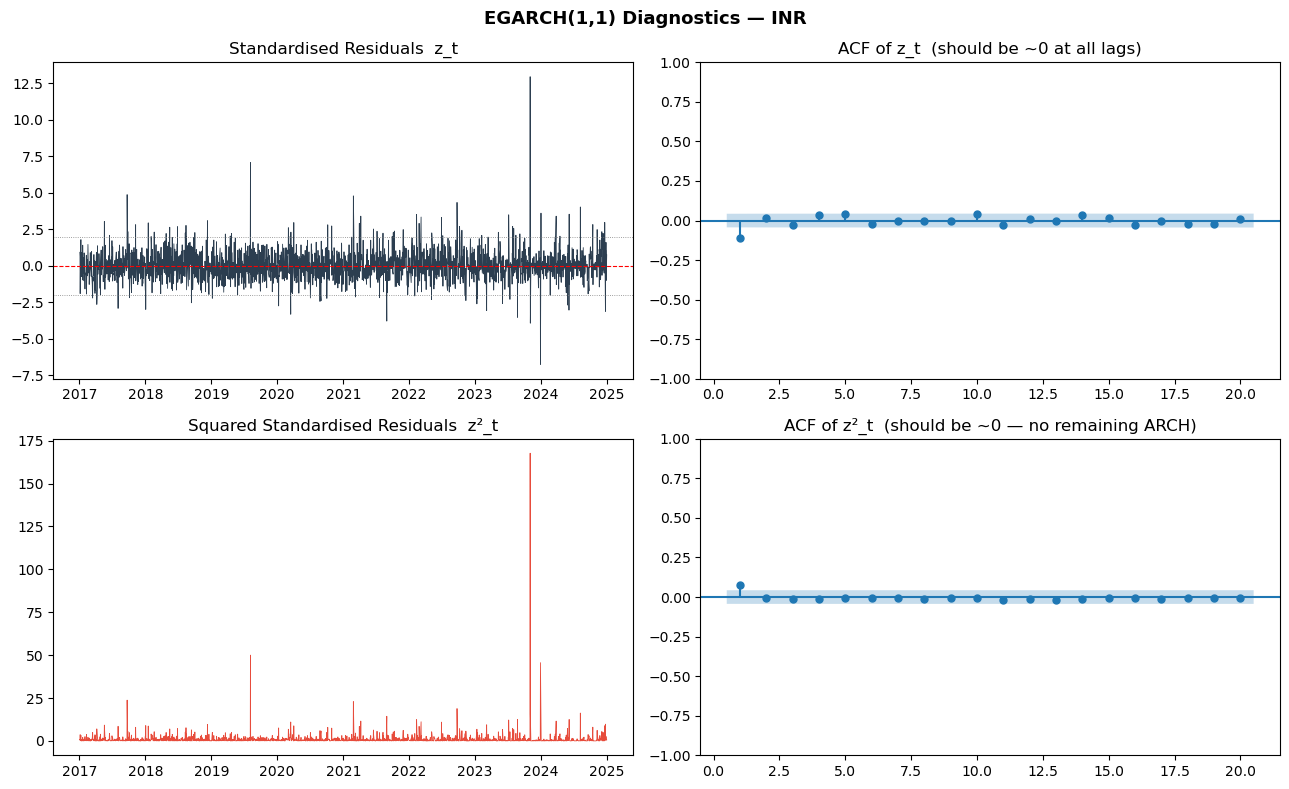

  Saved: ../results/figures\brics_diag_CNY.png


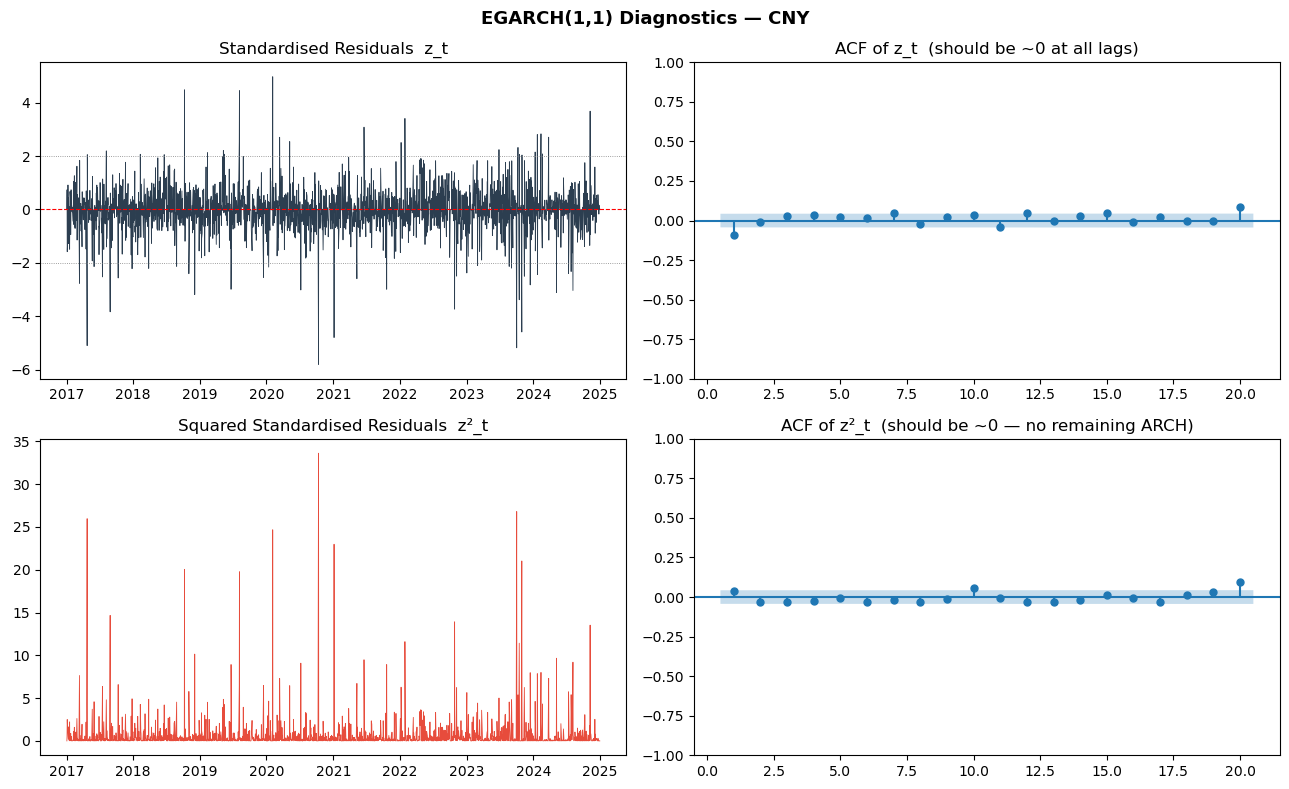

  Saved: ../results/figures\brics_diag_ZAR.png


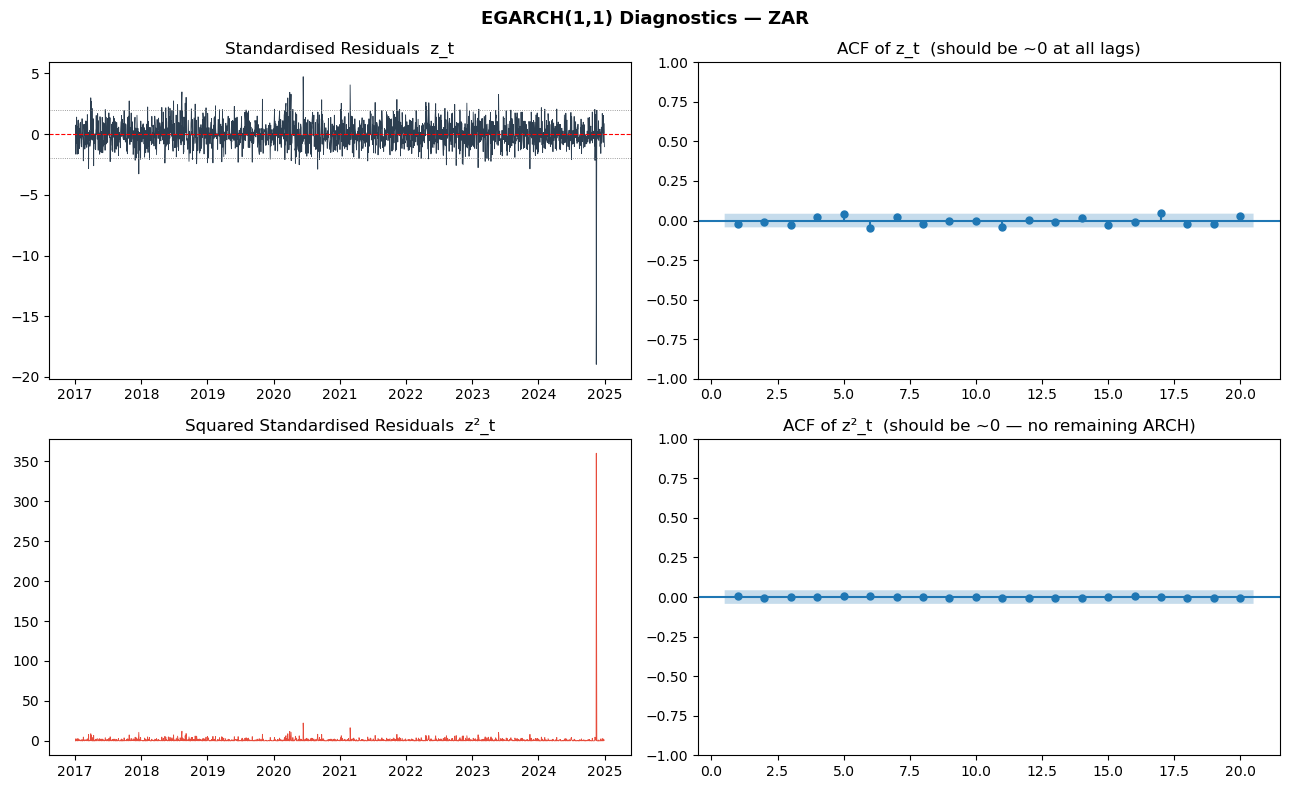

In [15]:
# =============================================================================
# STEP 8e — Per-Currency EGARCH Diagnostic Grids
# =============================================================================

def plot_egarch_diagnostics(egarch_results: dict,
                             save_prefix: str = None) -> None:
    """
    2×2 diagnostic grid per currency:
      [0,0] Standardised residuals z_t
      [0,1] ACF of z_t   (should show no significant autocorrelation)
      [1,0] Squared standardised residuals z²_t
      [1,1] ACF of z²_t  (should show no remaining ARCH effects)
    """
    for col, d in egarch_results.items():
        res       = d["result"]
        std_resid = (res.resid / res.conditional_volatility).dropna()

        fig = plt.figure(figsize=(13, 8))
        fig.suptitle(f"EGARCH(1,1) Diagnostics — {col}",
                     fontsize=13, fontweight="bold")
        gs  = gridspec.GridSpec(2, 2, figure=fig)
        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        ax3 = fig.add_subplot(gs[1, 0])
        ax4 = fig.add_subplot(gs[1, 1])

        ax1.plot(std_resid.index, std_resid.values, lw=0.6, color="#2c3e50")
        ax1.axhline(0,  color="red",  lw=0.8, ls="--")
        ax1.axhline( 2, color="grey", lw=0.6, ls=":")
        ax1.axhline(-2, color="grey", lw=0.6, ls=":")
        ax1.set_title("Standardised Residuals  z_t")

        plot_acf(std_resid.values, lags=20, ax=ax2, zero=False)
        ax2.set_title("ACF of z_t  (should be ~0 at all lags)")

        ax3.plot(std_resid.index, std_resid.values**2,
                 lw=0.6, color="#e74c3c")
        ax3.set_title("Squared Standardised Residuals  z²_t")

        plot_acf(std_resid.values**2, lags=20, ax=ax4, zero=False)
        ax4.set_title("ACF of z²_t  (should be ~0 — no remaining ARCH)")

        plt.tight_layout()
        if save_prefix:
            path = f"{save_prefix}_{col}.png"
            plt.savefig(path, dpi=150, bbox_inches="tight")
            print(f"  Saved: {path}")
        plt.show()


plot_egarch_diagnostics(
    egarch_results,
    save_prefix=os.path.join(FIG_DIR, "brics_diag")
)

---
## Step 9 — Export Results

All tables are saved to `results/tables/` and `data/processed/`.

In [16]:
# =============================================================================
# STEP 9 — EXPORT ALL RESULTS
# =============================================================================

def export_results(metrics, constraints, pre_diag, post_diag,
                   out_dir=TABLE_DIR):
    """Save all result tables to CSV."""
    os.makedirs(out_dir, exist_ok=True)

    metrics.to_csv(os.path.join(out_dir, "egarch_volatility_metrics.csv"))
    pre_diag.to_csv(os.path.join(out_dir, "prefit_diagnostics.csv"))
    post_diag.to_csv(os.path.join(out_dir, "postfit_diagnostics.csv"))

    wt_df = pd.DataFrame({
        "Currency":       constraints["ordered_currencies"],
        "Stability Rank": range(1, len(constraints["ordered_currencies"]) + 1),
        "Mean Cond Var":  [constraints["mean_cond_var"][c]
                           for c in constraints["ordered_currencies"]],
        "IV Weight":      [constraints["iv_weights"][c]
                           for c in constraints["ordered_currencies"]],
        "IV Weight (%)": [constraints["iv_weights"][c] * 100
                           for c in constraints["ordered_currencies"]],
    })
    wt_df.to_csv(os.path.join(out_dir, "egarch_weights.csv"), index=False)

    print(f"[9] Results exported to '{out_dir}/':")
    for f in ["egarch_volatility_metrics.csv", "prefit_diagnostics.csv",
              "postfit_diagnostics.csv", "egarch_weights.csv"]:
        print(f"    {f}")


export_results(metrics, constraints, pre_diag, post_diag)

[9] Results exported to '../results/tables/':
    egarch_volatility_metrics.csv
    prefit_diagnostics.csv
    postfit_diagnostics.csv
    egarch_weights.csv


---
## Final Summary — UNIT Basket Weights

Summary of all results and the final UNIT composition.

In [17]:
# =============================================================================
# FINAL SUMMARY
# =============================================================================

ordered = constraints["ordered_currencies"]
weights = constraints["iv_weights"]

print("=" * 65)
print("  BRICS CURRENCY UNIT — FINAL WEIGHT CONSTRAINTS")
print("=" * 65)
print("\n  UNIT = 0.6 × [Σ wᵢ · FXᵢ] + 0.4 × Gold")
print("\n  EGARCH-derived ordering constraint:")
print("    " + " ≥ ".join([f"w_{c}" for c in ordered]))
print("\n  Inverse-variance weights (analytically derived):")
for c in ordered:
    w   = weights[c]
    bar = '█' * int(w * 50)
    print(f"    w_{c} = {w:.4f}  ({w * 100:.2f}%)  {bar}")
print(f"\n  Σ weights = {weights.sum():.6f}  ✓")
print()
print("  Key finding: INR + CNY account for ~85% of the basket weight.")
print("  The Russian Ruble's near-zero weight is an empirical result")
print("  driven by its post-2022 sanctions structural break (α+β > 2).")
print("=" * 65)

  BRICS CURRENCY UNIT — FINAL WEIGHT CONSTRAINTS

  UNIT = 0.6 × [Σ wᵢ · FXᵢ] + 0.4 × Gold

  EGARCH-derived ordering constraint:
    w_INR ≥ w_CNY ≥ w_ZAR ≥ w_BRL ≥ w_RUB

  Inverse-variance weights (analytically derived):
    w_INR = 0.4667  (46.67%)  ███████████████████████
    w_CNY = 0.3895  (38.95%)  ███████████████████
    w_ZAR = 0.0748  (7.48%)  ███
    w_BRL = 0.0689  (6.89%)  ███
    w_RUB = 0.0000  (0.00%)  

  Σ weights = 1.000000  ✓

  Key finding: INR + CNY account for ~85% of the basket weight.
  The Russian Ruble's near-zero weight is an empirical result
  driven by its post-2022 sanctions structural break (α+β > 2).


---
## References

- Nelson, D. B. (1991). Conditional heteroskedasticity in asset returns: A new approach. *Econometrica*, 59(2), 347–370.
- Bollerslev, T. (1986). Generalized autoregressive conditional heteroskedasticity. *Journal of Econometrics*, 31(3), 307–327.
- Engle, R. F. (1982). Autoregressive conditional heteroscedasticity with estimates of the variance of United Kingdom inflation. *Econometrica*, 50(4), 987–1007.
- Jain, A., & Tripathy, T. (2021). Estimating and forecasting BRICS currency exchange rate volatility. *Cogent Economics & Finance*, 9(1), 1985777.
- World Bank (2024). World Development Indicators. https://databank.worldbank.org/source/world-development-indicators
- Mundell, R. A. (1961). A theory of optimum currency areas. *American Economic Review*, 51(4), 657–665.

---